In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import warnings; warnings.simplefilter('ignore')
import sys
import h5py
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_visualize
import jsm_SHMR
import jsm_mcmc
import jsm_stats
import jsm_models
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg
import pygtc

In [3]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

In [4]:
# S0 = jsm_ancillary.load_sample("../../data/MW/S0_fid.h5")
# S15 = jsm_ancillary.load_sample("../../data/MW/S15_fid.h5")
# S30 = jsm_ancillary.load_sample("../../data/MW/S30_fid.h5")

# S0_clean = jsm_ancillary.clean_sample(S0, "withering")
# S15_clean = jsm_ancillary.clean_sample(S15, "withering")
# S30_clean = jsm_ancillary.clean_sample(S30, "withering")

# S0_clean.to_csv("../../data/summary_tabs/MW/withering/S0.csv")
# S15_clean.to_csv("../../data/summary_tabs/MW/withering/S15.csv")
# S30_clean.to_csv("../../data/summary_tabs/MW/withering/S30.csv")

In [5]:
S0_withering = pd.read_csv("../../data/summary_tabs/MW/withering/S0.csv")
S15_withering = pd.read_csv("../../data/summary_tabs/MW/withering/S15.csv")
S30_withering = pd.read_csv("../../data/summary_tabs/MW/withering/S30.csv")

S0_Rvir = pd.read_csv("../../data/summary_tabs/MW/Rvir/S0.csv")
S15_Rvir = pd.read_csv("../../data/summary_tabs/MW/Rvir/S15.csv")
S30_Rvir = pd.read_csv("../../data/summary_tabs/MW/Rvir/S30.csv")

S0_artificial = pd.read_csv("../../data/summary_tabs/MW/artificial/S0.csv")
S15_artificial = pd.read_csv("../../data/summary_tabs/MW/artificial/S15.csv")
S30_artificial = pd.read_csv("../../data/summary_tabs/MW/artificial/S30.csv")

sym_fid = pd.read_csv("../../data/summary_tabs/MW/symphony/m12s.csv")

(0.0, 25.0)

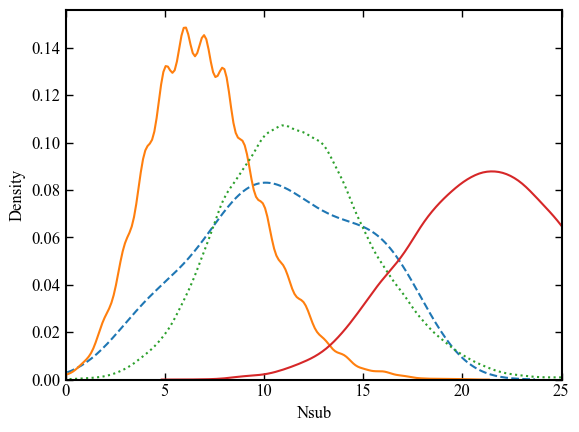

In [6]:
sns.kdeplot(sym_fid["Nsub"], ls="--")
sns.kdeplot(S0_artificial["Nsub"])
sns.kdeplot(S0_Rvir["Nsub"], ls=":")
sns.kdeplot(S0_withering["Nsub"])

plt.xlim(0,25)

In [7]:
cols = ["log1pz50", "logc", "logNsub", "logfsub", "logMMs"]

S0_artificial_clean = (
    S0_artificial[cols]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

S0_Rvir_clean = (
    S0_Rvir[cols]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

S0_withering_clean = (
    S0_withering[cols]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

In [8]:
truth_sym = sym_fid[cols].median()

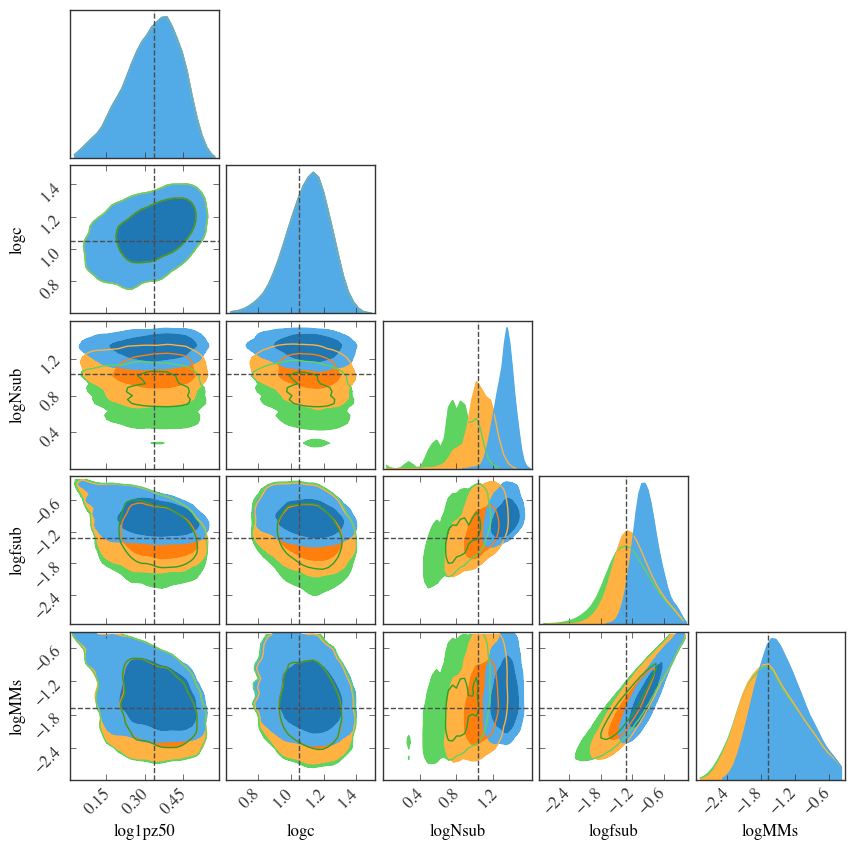

In [9]:
# corner plot
corner_comp = pygtc.plotGTC(
    chains=[S0_withering_clean, S0_Rvir_clean, S0_artificial_clean],
    figureSize=10,
    truths = truth_sym.to_list(),
    customTickFont={'family':'Times', 'size':12},
    customLegendFont={'family':'Times', 'size':12},
    customLabelFont={'family':'Times', 'size':12},
    mathTextFontSet=None,
    panelSpacing='loose')

In [10]:
def sample_size_rho(df, chunk_size=45):

    chunks = [
        df.iloc[i:i + chunk_size]
        for i in range(0, len(df), chunk_size)]

    n_chunks = len(chunks)

    rho_mat = np.empty((n_chunks, 3))
    rho_err_mat = np.empty((n_chunks, 3))
    pval_mat = np.empty((n_chunks, 3))

    for i, chunk in enumerate(chunks):

        rho_z, rho_err_z, pval_z = jsm_stats.jackknife_correlation(
            chunk["log1pz50"], chunk["Nsub"])

        rho_c, rho_err_c, pval_c = jsm_stats.jackknife_correlation(
            chunk["logc"], chunk["Nsub"])

        rho_m, rho_err_m, pval_m = jsm_stats.jackknife_correlation(
            chunk["MMs"], chunk["Nsub"])

        rho_mat[i] = [rho_z, rho_c, rho_m]
        rho_err_mat[i] = [rho_err_z, rho_err_c, rho_err_m]
        pval_mat[i] = [pval_z, pval_c, pval_m]

    weights = 1.0 / rho_err_mat**2
    rho_weighted_mean = np.sum(weights * rho_mat, axis=0) / np.sum(weights, axis=0)

    return rho_mat, rho_err_mat, pval_mat, rho_weighted_mean

In [ ]:
sym_rhoz_fid, sym_rho_errz_fid, _ = jsm_stats.jackknife_correlation(sym_fid["log1pz50"], sym_fid["Nsub"])

sym_rhoc_fid, sym_rho_errc_fid, _ = jsm_stats.jackknife_correlation(sym_fid["logc"], sym_fid["Nsub"])

sym_rhom_fid, sym_rho_errm_fid, _ = jsm_stats.jackknife_correlation(sym_fid["MMs"], sym_fid["Nsub"])

In [12]:
rho_mat_S0, rho_err_mat_S0, pval_mat_S0, wmean_S0 = sample_size_rho(S0_withering)

rho_mat_S15, rho_err_mat_S15, pval_mat_S15, wmean_S15 = sample_size_rho(S15_withering)

rho_mat_S30, rho_err_mat_S30, pval_mat_S30, wmean_S30 = sample_size_rho(S30_withering)

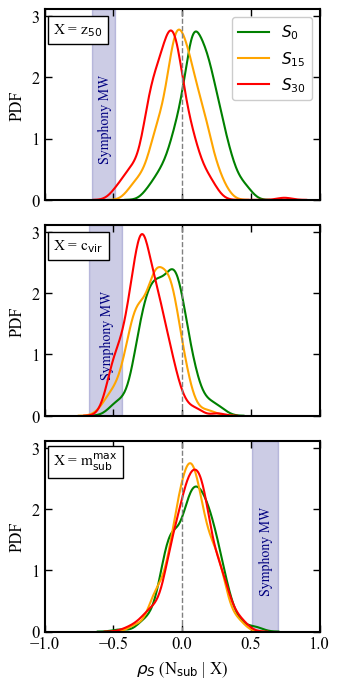

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(single_textwidth, double_textwidth), sharex=True, sharey=True)

### LEGEND
myHandle = [Line2D([], [], color='green', lw = 1.5), Line2D([], [], color='orange', lw = 1.5), Line2D([], [], color='red', lw = 1.5)]
axes[0].legend(handles = myHandle, labels=['$S_0$', '$S_{15}$', '$S_{30}$',], loc=1, framealpha=1, fontsize=11)

axes[0].text(0.03, 0.87, s="X = z$_{50}$", transform=axes[0].transAxes, fontsize=11, bbox=dict(facecolor='white', alpha=1, edgecolor="k"))
axes[1].text(0.03, 0.87, s="X = c$_{\\rm vir}$", transform=axes[1].transAxes, fontsize=11, bbox=dict(facecolor='white', alpha=1, edgecolor="k"))
axes[2].text(0.03, 0.87, s="X = m$_{\\rm sub}^{\\rm max}$", transform=axes[2].transAxes, fontsize=11, bbox=dict(facecolor='white', alpha=1, edgecolor="k"))

sns.kdeplot(rho_mat_S0[:, 0], color="green", ax=axes[0])
sns.kdeplot(rho_mat_S15[:, 0], color="orange", ax=axes[0])
sns.kdeplot(rho_mat_S30[:, 0], color="red", ax=axes[0])

sns.kdeplot(rho_mat_S0[:, 1], color="green", ax=axes[1])
sns.kdeplot(rho_mat_S15[:, 1], color="orange", ax=axes[1])
sns.kdeplot(rho_mat_S30[:, 1], color="red", ax=axes[1])

sns.kdeplot(rho_mat_S0[:, 2], color="green", ax=axes[2])
sns.kdeplot(rho_mat_S15[:, 2], color="orange", ax=axes[2])
sns.kdeplot(rho_mat_S30[:, 2], color="red", ax=axes[2])

axes[0].axvspan(sym_rhoz_fid-sym_rho_errz_fid, sym_rhoz_fid+sym_rho_errz_fid, color="navy", alpha=0.2)
axes[1].axvspan(sym_rhoc_fid-sym_rho_errc_fid, sym_rhoc_fid+sym_rho_errc_fid, color="navy", alpha=0.2, label="Symphony MW")
axes[2].axvspan(sym_rhom_fid-sym_rho_errm_fid, sym_rhom_fid+sym_rho_errm_fid, color="navy", alpha=0.2)

axes[0].text(-0.61, 0.65, s="Symphony MW", rotation='vertical', c="navy")
axes[1].text(-0.6, 0.65, s="Symphony MW", rotation='vertical', c="navy", zorder=0)
axes[2].text(0.56, 0.65, s="Symphony MW", rotation='vertical', c="navy", zorder=0)

axes[0].set_xlim(-1,1)
for ax in axes:
    ax.axvline(0, ls="--", color="grey", lw=1)
    ax.set_ylabel("PDF")

axes[2].set_xlabel("$\\rho_S$ (N$_{\\rm sub}$ | X)")
plt.tight_layout()

In [14]:
rho_mat_S0, rho_err_mat_S0, pval_mat_S0, wmean_S0 = sample_size_rho(S0_Rvir)

rho_mat_S15, rho_err_mat_S15, pval_mat_S15, wmean_S15 = sample_size_rho(S15_Rvir)

rho_mat_S30, rho_err_mat_S30, pval_mat_S30, wmean_S30 = sample_size_rho(S30_Rvir)

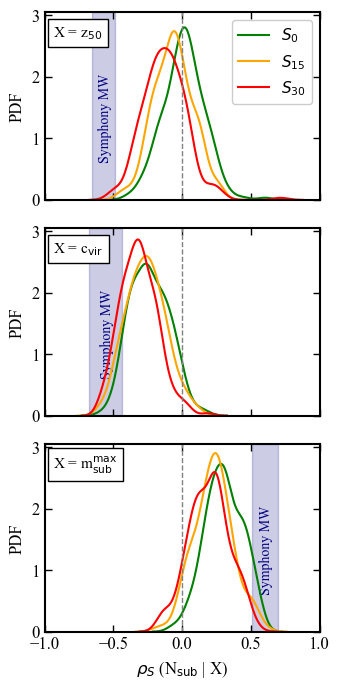

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(single_textwidth, double_textwidth), sharex=True, sharey=True)

### LEGEND
myHandle = [Line2D([], [], color='green', lw = 1.5), Line2D([], [], color='orange', lw = 1.5), Line2D([], [], color='red', lw = 1.5)]
axes[0].legend(handles = myHandle, labels=['$S_0$', '$S_{15}$', '$S_{30}$',], loc=1, framealpha=1, fontsize=11)

axes[0].text(0.03, 0.87, s="X = z$_{50}$", transform=axes[0].transAxes, fontsize=11, bbox=dict(facecolor='white', alpha=1, edgecolor="k"))
axes[1].text(0.03, 0.87, s="X = c$_{\\rm vir}$", transform=axes[1].transAxes, fontsize=11, bbox=dict(facecolor='white', alpha=1, edgecolor="k"))
axes[2].text(0.03, 0.87, s="X = m$_{\\rm sub}^{\\rm max}$", transform=axes[2].transAxes, fontsize=11, bbox=dict(facecolor='white', alpha=1, edgecolor="k"))

sns.kdeplot(rho_mat_S0[:, 0], color="green", ax=axes[0])
sns.kdeplot(rho_mat_S15[:, 0], color="orange", ax=axes[0])
sns.kdeplot(rho_mat_S30[:, 0], color="red", ax=axes[0])

sns.kdeplot(rho_mat_S0[:, 1], color="green", ax=axes[1])
sns.kdeplot(rho_mat_S15[:, 1], color="orange", ax=axes[1])
sns.kdeplot(rho_mat_S30[:, 1], color="red", ax=axes[1])

sns.kdeplot(rho_mat_S0[:, 2], color="green", ax=axes[2])
sns.kdeplot(rho_mat_S15[:, 2], color="orange", ax=axes[2])
sns.kdeplot(rho_mat_S30[:, 2], color="red", ax=axes[2])

axes[0].axvspan(sym_rhoz_fid-sym_rho_errz_fid, sym_rhoz_fid+sym_rho_errz_fid, color="navy", alpha=0.2)
axes[1].axvspan(sym_rhoc_fid-sym_rho_errc_fid, sym_rhoc_fid+sym_rho_errc_fid, color="navy", alpha=0.2, label="Symphony MW")
axes[2].axvspan(sym_rhom_fid-sym_rho_errm_fid, sym_rhom_fid+sym_rho_errm_fid, color="navy", alpha=0.2)

axes[0].text(-0.61, 0.65, s="Symphony MW", rotation='vertical', c="navy")
axes[1].text(-0.6, 0.65, s="Symphony MW", rotation='vertical', c="navy", zorder=0)
axes[2].text(0.56, 0.65, s="Symphony MW", rotation='vertical', c="navy", zorder=0)

axes[0].set_xlim(-1,1)
for ax in axes:
    ax.axvline(0, ls="--", color="grey", lw=1)
    ax.set_ylabel("PDF")

axes[2].set_xlabel("$\\rho_S$ (N$_{\\rm sub}$ | X)")
plt.tight_layout()

In [18]:
rho_mat_S0, rho_err_mat_S0, pval_mat_S0, wmean_S0 = sample_size_rho(S0_artificial)

rho_mat_S15, rho_err_mat_S15, pval_mat_S15, wmean_S15 = sample_size_rho(S15_artificial)

rho_mat_S30, rho_err_mat_S30, pval_mat_S30, wmean_S30 = sample_size_rho(S30_artificial)

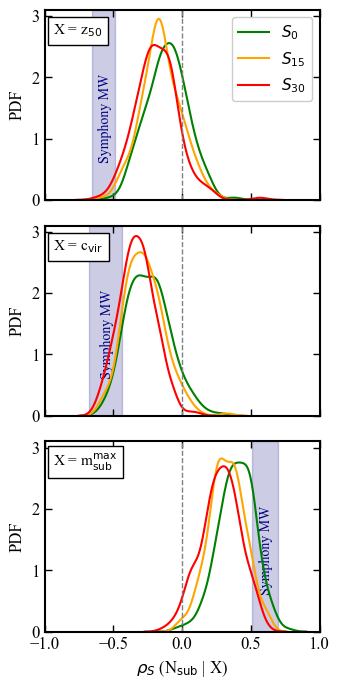

In [19]:
fig, axes = plt.subplots(3, 1, figsize=(single_textwidth, double_textwidth), sharex=True, sharey=True)

### LEGEND
myHandle = [Line2D([], [], color='green', lw = 1.5), Line2D([], [], color='orange', lw = 1.5), Line2D([], [], color='red', lw = 1.5)]
axes[0].legend(handles = myHandle, labels=['$S_0$', '$S_{15}$', '$S_{30}$',], loc=1, framealpha=1, fontsize=11)

axes[0].text(0.03, 0.87, s="X = z$_{50}$", transform=axes[0].transAxes, fontsize=11, bbox=dict(facecolor='white', alpha=1, edgecolor="k"))
axes[1].text(0.03, 0.87, s="X = c$_{\\rm vir}$", transform=axes[1].transAxes, fontsize=11, bbox=dict(facecolor='white', alpha=1, edgecolor="k"))
axes[2].text(0.03, 0.87, s="X = m$_{\\rm sub}^{\\rm max}$", transform=axes[2].transAxes, fontsize=11, bbox=dict(facecolor='white', alpha=1, edgecolor="k"))

sns.kdeplot(rho_mat_S0[:, 0], color="green", ax=axes[0])
sns.kdeplot(rho_mat_S15[:, 0], color="orange", ax=axes[0])
sns.kdeplot(rho_mat_S30[:, 0], color="red", ax=axes[0])

sns.kdeplot(rho_mat_S0[:, 1], color="green", ax=axes[1])
sns.kdeplot(rho_mat_S15[:, 1], color="orange", ax=axes[1])
sns.kdeplot(rho_mat_S30[:, 1], color="red", ax=axes[1])

sns.kdeplot(rho_mat_S0[:, 2], color="green", ax=axes[2])
sns.kdeplot(rho_mat_S15[:, 2], color="orange", ax=axes[2])
sns.kdeplot(rho_mat_S30[:, 2], color="red", ax=axes[2])

axes[0].axvspan(sym_rhoz_fid-sym_rho_errz_fid, sym_rhoz_fid+sym_rho_errz_fid, color="navy", alpha=0.2)
axes[1].axvspan(sym_rhoc_fid-sym_rho_errc_fid, sym_rhoc_fid+sym_rho_errc_fid, color="navy", alpha=0.2, label="Symphony MW")
axes[2].axvspan(sym_rhom_fid-sym_rho_errm_fid, sym_rhom_fid+sym_rho_errm_fid, color="navy", alpha=0.2)

axes[0].text(-0.61, 0.65, s="Symphony MW", rotation='vertical', c="navy")
axes[1].text(-0.6, 0.65, s="Symphony MW", rotation='vertical', c="navy", zorder=0)
axes[2].text(0.56, 0.65, s="Symphony MW", rotation='vertical', c="navy", zorder=0)

axes[0].set_xlim(-1,1)
for ax in axes:
    ax.axvline(0, ls="--", color="grey", lw=1)
    ax.set_ylabel("PDF")

axes[2].set_xlabel("$\\rho_S$ (N$_{\\rm sub}$ | X)")
plt.tight_layout()